# Wine Quality pH Analysis

**Student:** Temur Rustamov (C00280204)  
**Module:** Data Science & Machine Learning  
**Assessment:** Continuous Assessment – Data Science & ML Portfolio  
**Item:** Wine Quality pH Prediction (Regression)

## Project Overview

This notebook demonstrates a complete data science workflow: from data loading and exploration to building and evaluating regression models.

The goal of this project is to analyse the chemical properties of red wine and model how these properties influence **pH** (acidity). pH is a key characteristic in wine making: lower pH means more acidic wine.

## Dataset & Why I Chose It

- **Dataset:** `winequality-red.csv` (red wine quality dataset, commonly used in data science and ml examples).
- **Target chosen:** `pH` — a continuous variable suitable for regression.

I chose this dataset because:

- It is a **real-world**, well-known dataset with meaningful chemical features (acidity, sulphates, alcohol, density, etc.).
- It is **small enough** to explore fully in a notebook but **rich enough** to demonstrate:
  - Data cleaning  
  - Correlation analysis and visualisation  
  - Simple and multiple linear regression  
  - Model evaluation and interpretation
- Predicting **pH** instead of just “quality” lets me focus on a clear **regression problem** with an interpretable scientific meaning (acidity).

## Tools / Technologies Used (and Why)

- **Python** – standard language for data science, with strong ecosystem support.
- **Jupyter Notebook** – allows mixing code, output and explanation in one document, ideal for this assessment.
- **pandas** – convenient data loading, cleaning and transformation.
- **NumPy** – numerical operations, creating regression lines, etc.
- **matplotlib & seaborn** – visualisation of correlations and regression fits.
- **scikit-learn** – regression models, data splitting, scaling, and evaluation metrics.

These tools are widely used in industry and academia, and they support a reproducible, transparent workflow.

## Why Pandas

>I chose pandas for data loading and manipulation because it is specifically designed for working with tabular data (rows and columns) like the wine dataset. It provides convenient operations for reading CSV files, exploring data with .head(), .info(), .describe(),filtering, grouping and transforming columns.

## Why NumPy
>I used NumPy mainly for numerical operations such as creating sequences for regression lines and working with arrays. NumPy is highly optimised for numerical computation and integrates seamlessly with both pandas and scikit-learn, which internally work with NumPy arrays. This makes data conversion and model training straightforward and efficient.

## Why matplot-lib
>I used matplotlib as the core plotting library and seaborn on top of it for higher-level statistical visualisation.matplotlib gives full control over plots (axes, labels, figure size), which is useful for custom visualisations such as residual plots and predicted vs actual plots.seaborn simplifies common statistical plots such as correlation heatmaps and scatter plots with nicer default styles.

## Data split
> I used train_test_split to divide the data into a training set (80%) and a test set (20%).Without such a split, it would be easy to overestimate model performance by evaluating on the same data used to fit the model. Using a separate test set gives a more honest estimate of how well the model is likely to generalise to new, unseen wines.
## Methodology

1. **Data loading & inspection**
   - Loaded the CSV file with `pandas`.
   - Verified shape, basic statistics and checked for missing values.

2. **Exploratory Data Analysis (EDA)**
   - Computed the correlation matrix and inspected correlations with `pH`.
   - Plotted a **correlation heatmap** with `seaborn` to visually identify which features relate most strongly to pH.

3. **Simple Linear Regression**
   - For each selected feature, built a **simple linear regression model**:
     - Feature → `pH`
     - Plotted data points and regression line to see the strength and direction of each relationship.

4. **Multiple Linear Regression**
   - Selected features based on correlation and domain intuition:
     - `fixed acidity`, `citric acid`, `density`, `chlorides`, `sulphates`, `volatile acidity`, `alcohol`.
   - Standardised features using `StandardScaler` so that coefficients are on comparable scales.
   - Split data into **train (80%) / test (20%)** using `train_test_split`.
   - Trained a `LinearRegression` model on the scaled features.

5. **Model Evaluation**
   - Evaluated model with:
     - **Mean Squared Error (MSE)**
     - **R-squared (R²)** on the test set.
   - Created:
     - **Residual plots** to check for randomness (a sign that the linear model is appropriate).
     - **Predicted vs actual** plots for both training and test sets.

## Model Choice 

I focused on **Linear Regression** (simple and multiple) because:

- It is **interpretable** – each coefficient shows how much pH changes when one feature changes, holding others constant.
- It is a natural first model for exploring **linear relationships** in continuous data.
- It fits the scope of this assessment: demonstrating the full e2e pipeline on a **clear, understandable model**.

## Key Findings

- **Fixed acidity** has the **strongest negative correlation** with pH:  
  higher fixed acidity → lower pH → more acidic wine.
- **Density** and **alcohol** show a **positive relationship** with pH, indicating slightly less acidity as these values increase.
- The **multiple linear regression** model for pH can be written approximately as:

  \[
  \text{pH} = 3.312 - 0.140 \cdot \text{fixed acidity}
              - 0.021 \cdot \text{citric acid}
              + 0.086 \cdot \text{density}
              - 0.021 \cdot \text{chlorides}
              - 0.011 \cdot \text{sulphates}
              - 0.003 \cdot \text{volatile acidity}
              + 0.065 \cdot \text{alcohol}
  \]

- The model achieved an **R² ≈ 0.65** on the test set:
  - It explains around **65% of the variation** in pH.
  - This indicates a **moderately strong and reliable** predictive model for this dataset.

## Limitations & Future Work

- The model only captures **linear** relationships; real-world chemistry may involve non-linear interactions.
- No advanced **feature engineering** or interaction terms were explored.
- Only one main model (linear regression) was evaluated.

With more time, I would:

- Try non-linear models (e.g. Random Forest, Gradient Boosting).
- Explore interaction terms between acidity measures.
- Perform more systematic **hyperparameter tuning** and cross-validation.
- Investigate domain-specific transformations of chemical features.

## Conclusion

This project shows that pH in red wine is primarily driven by acidity-related features, especially fixed acidity, with additional contributions from density and alcohol. A multiple linear regression model can capture a substantial portion of the variability in pH and produce realistic predictions, making it a useful, interpretable baseline model for this problem.


In [58]:
import pandas  as pd #Data manipulation
import matplotlib.pyplot as plt # Visualization
import seaborn as sns
sns.set_style("whitegrid") #Style
plt.rcParams['figure.figsize'] = [8,5] #Default plot size
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'

In [ ]:
path = './data/' #Path to data set
df = pd.read_csv(path+'winequality-red.csv', delimiter = ';') #To load csv data
print('\nNumber of rows and columns in the data set:', df.shape)
print('')
df.head() #First 5 rows


Number of rows and columns in the data set: (1599, 12)



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [60]:
print(df.isnull().sum()) #Check for missing values in each column

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [61]:
corr_matrix = df.corr() #Compute correlation matrix
print(corr_matrix['pH']) #Correlation of all features with ph

fixed acidity          -0.682978
volatile acidity        0.234937
citric acid            -0.541904
residual sugar         -0.085652
chlorides              -0.265026
free sulfur dioxide     0.070377
total sulfur dioxide   -0.066495
density                -0.341699
pH                      1.000000
sulphates              -0.196648
alcohol                 0.205633
quality                -0.057731
Name: pH, dtype: float64


In [62]:
print(df.corr()['pH'].sort_values(ascending=False)) # Show features most correlated with pH in descending order


pH                      1.000000
volatile acidity        0.234937
alcohol                 0.205633
free sulfur dioxide     0.070377
quality                -0.057731
total sulfur dioxide   -0.066495
residual sugar         -0.085652
sulphates              -0.196648
chlorides              -0.265026
density                -0.341699
citric acid            -0.541904
fixed acidity          -0.682978
Name: pH, dtype: float64


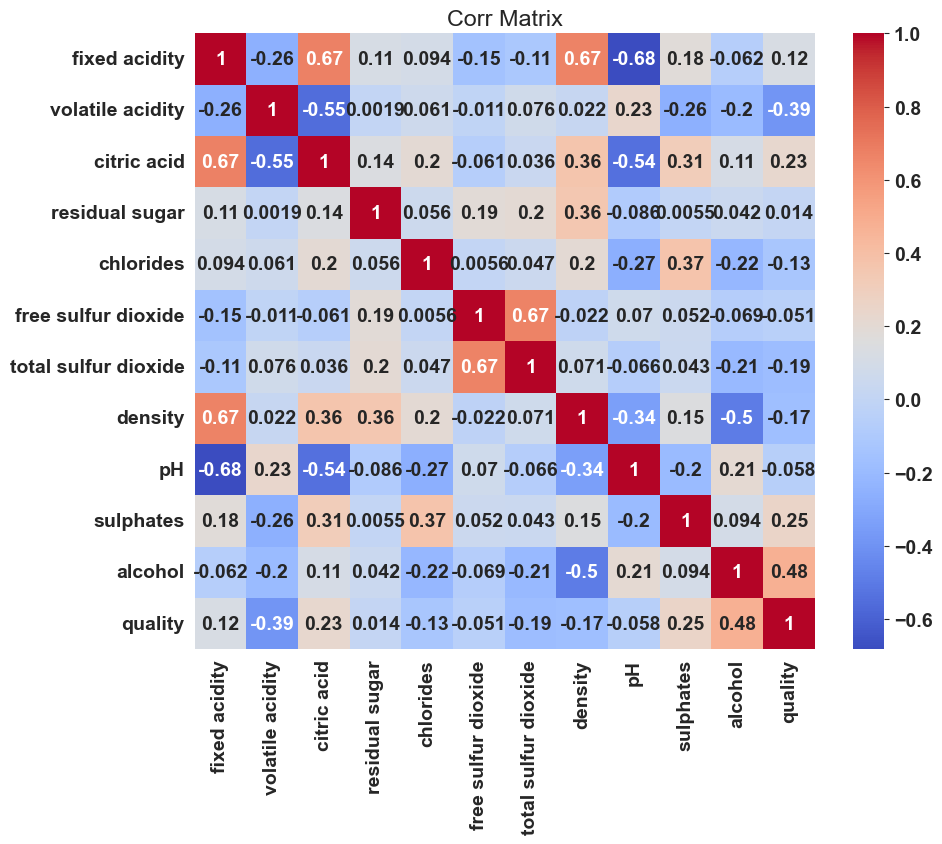

In [63]:
import matplotlib.pyplot as plt # Visualization
import seaborn as sns # Advanced plotting
sns.set_style("whitegrid")
plt.figure(figsize = (10,8)) #Plot size
sns.heatmap(df.corr(), annot=True, cmap ='coolwarm') #Correlation heatmap
plt.title('Corr Matrix') #Title
plt.show() #Plot itself

Feature: fixed acidity, Intercept: 3.814959011196921, Coef: -0.060561031556845966


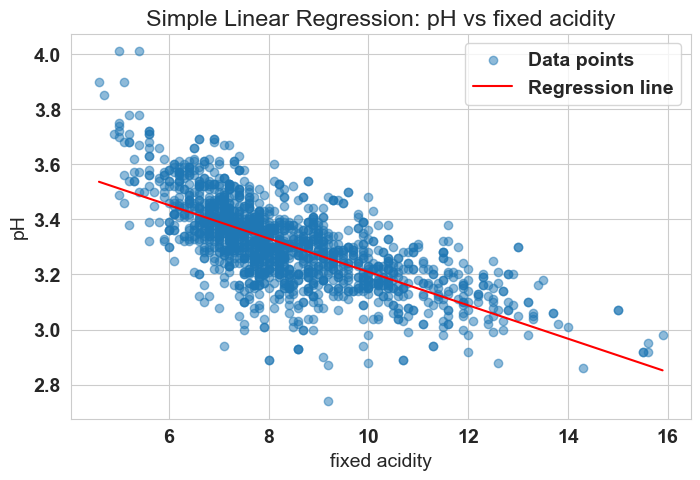

Feature: citric acid, Intercept: 3.427491067173361, Coef: -0.42947729329134027


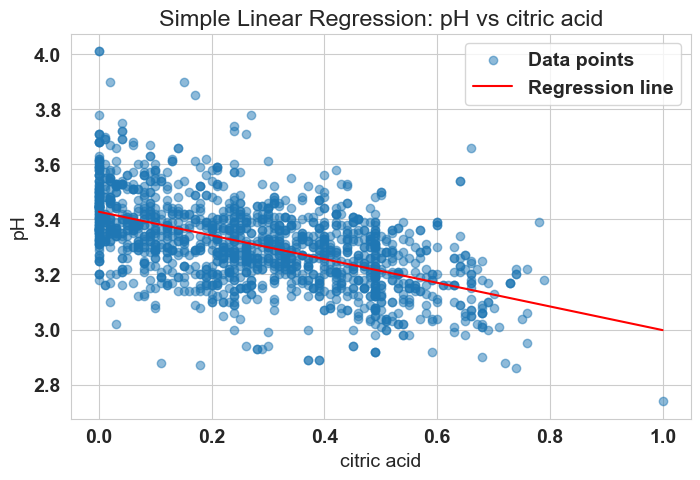

Feature: density, Intercept: 31.17164490987732, Coef: -27.95146680318449


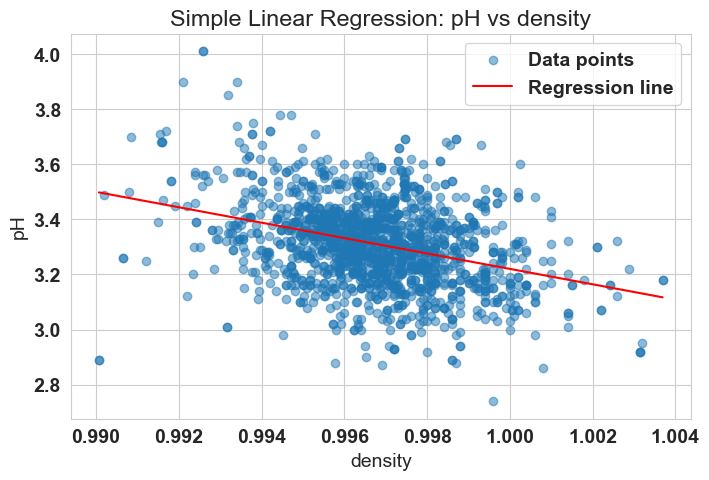

Feature: chlorides, Intercept: 3.38715265590099, Coef: -0.8693548272594801


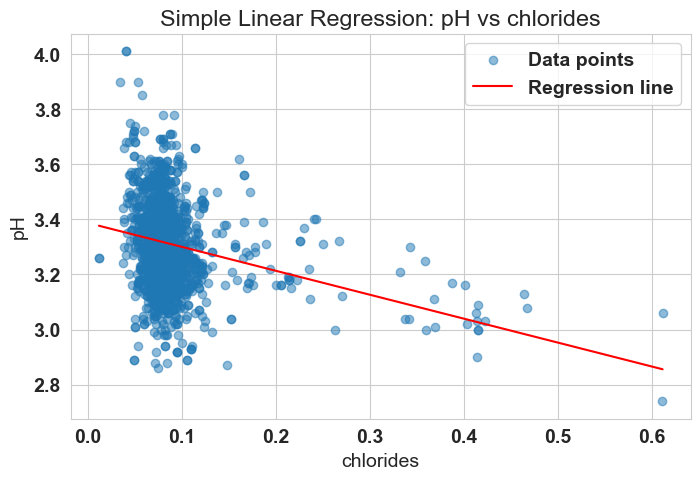

Feature: sulphates, Intercept: 3.4289916453891043, Coef: -0.17910606527792106


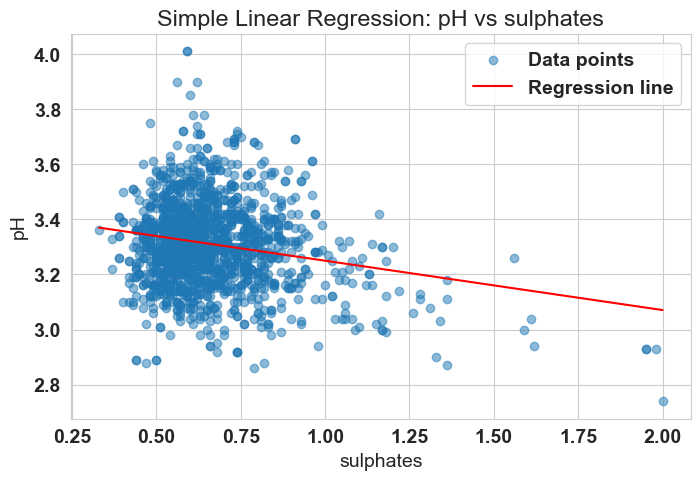

Feature: volatile acidity, Intercept: 3.2041955006747775, Coef: 0.20256449394364848


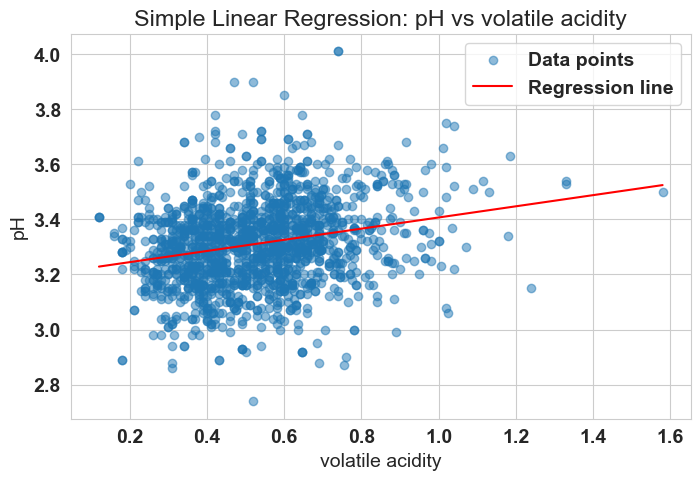

Feature: alcohol, Intercept: 3.0006062809088525, Coef: 0.029790599430993832


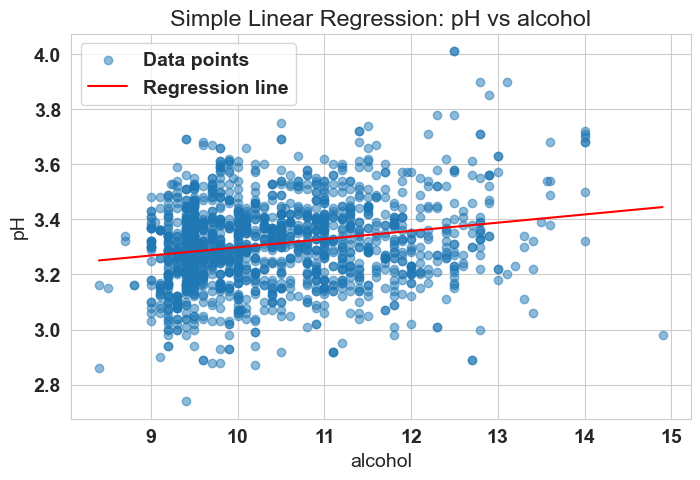

Mean Squared Error: 0.008413891809564152
R-squared (test): 0.653551476495621
Multiple Linear Regression Equation:
pH = 3.312 + (-0.140 * fixed acidity) + (-0.021 * citric acid) + (0.086 * density) + (-0.021 * chlorides) + (-0.011 * sulphates) + (-0.003 * volatile acidity) + (0.065 * alcohol)


In [64]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression # Linear regression model
import numpy as np # Numerical operations
# Selected features for regression
selected_features = [
    'fixed acidity', 'citric acid', 'density',
    'chlorides', 'sulphates', 'volatile acidity', 'alcohol'
]

#Simple Linear Regressiion
for feature in selected_features:
    X = df[[feature]].values # Independent variable
    Y = df['pH'].values  # Dependent variable
    model = LinearRegression()
    model.fit(X,Y)  # Train model
    intercept = model.intercept_
    coef = model.coef_[0]
    print(f"Feature: {feature}, Intercept: {intercept}, Coef: {coef}")
    # Plot regression line
    x_line = np.linspace(X.min(), X.max(),100)
    y_line = intercept + coef * x_line
    plt.figure(figsize=(8,5))
    plt.scatter(X,Y, alpha=0.5, label='Data points')
    plt.plot(x_line, y_line, color='red', label='Regression line')
    plt.xlabel(feature)
    plt.ylabel('pH')
    plt.title(f'Simple Linear Regression: pH vs {feature}')
    plt.legend()
    plt.show()


# Multi-linear Regression set up
X = df[selected_features]        # Independent variables
Y = df['pH'] #Target

# Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import train_test_split # Split train-test data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

model = LinearRegression() # Fit multiple regression model
model.fit(X_train, y_train)

# Evaluate model
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared (test):", r2_score(y_test, y_pred))

# Print the regression equation
intercept = model.intercept_
coefficients = model.coef_
equation = f"pH = {intercept:.3f}"
for coef, feat in zip(coefficients, selected_features):
    equation += f" + ({coef:.3f} * {feat})"
print("Multiple Linear Regression Equation:")
print(equation)

In [65]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()  # Initialize scaler
X_scaled = scaler.fit_transform(X) # Scale features with mean to 0
print(X_scaled) # Display standardized values

[[-0.52835961 -1.39147228  0.55827446 ... -0.57920652  0.96187667
  -0.96024611]
 [-0.29854743 -1.39147228  0.02826077 ...  0.1289504   1.96744245
  -0.58477711]
 [-0.29854743 -1.18607043  0.13426351 ... -0.04808883  1.29706527
  -0.58477711]
 ...
 [-1.1603431  -0.72391627 -0.53355375 ...  0.54204194 -0.09955388
   0.54162988]
 [-1.39015528 -0.77526673 -0.67665745 ...  0.30598963  0.65462046
  -0.20930812]
 [-1.33270223  1.02199944 -0.66605717 ...  0.01092425 -1.21684919
   0.54162988]]


In [66]:
from sklearn.model_selection import train_test_split # Split data into train and test sets
from sklearn.linear_model import LinearRegression # Linear regression model
from sklearn.metrics import mean_squared_error, r2_score # Evaluation metrics
import matplotlib.pyplot as plt # Visualization
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42) # Split data into training and testing sets
model = LinearRegression() # Train linear regression model
model.fit(X_train, y_train)
y_pred = model.predict(X_test) # Predict target
print(y_pred) # Predicted ph
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred)) # Measure model fit quality

[3.33588451 3.28898232 3.22806546 3.3255216  3.37702781 3.36111466
 3.30488608 3.3671302  3.25623557 3.48192445 3.19702913 3.40915512
 3.37507132 3.34666049 3.27449473 3.23357024 3.40619308 3.20205042
 3.24451274 3.24597801 3.44588618 3.28089714 3.453248   3.45590263
 3.33436302 3.39331647 3.23992471 3.39354227 3.42559091 3.11702331
 3.36038232 3.39533102 3.28849851 3.18615212 3.43023627 3.26328789
 3.39511039 3.45136735 3.05201607 3.31491291 3.03679247 3.26537568
 3.19087953 3.28495609 3.06144321 3.32476729 3.17097343 3.0283697
 3.3679822  3.3841656  3.39299265 3.04665493 3.35990582 3.56327497
 3.39971199 3.27152433 3.37353982 3.4574056  3.38064932 3.44278062
 3.37470773 3.17936937 3.31410364 3.3183325  3.12671491 3.25462445
 3.16410536 3.48747507 3.43151976 3.28040222 3.35039246 3.32819604
 3.26237482 3.44581077 3.36091076 3.16434468 3.52024661 3.3927475
 3.49340045 3.35102858 3.45052602 3.19554265 3.37449112 3.33564834
 3.37312197 3.16654788 3.2871829  3.43071301 3.2030037  3.492918

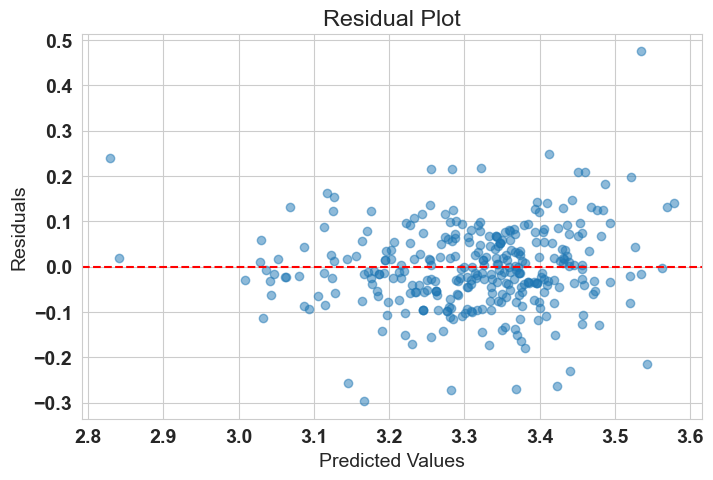

Text(0.5, 1.0, 'Predicted vs Actual Values')

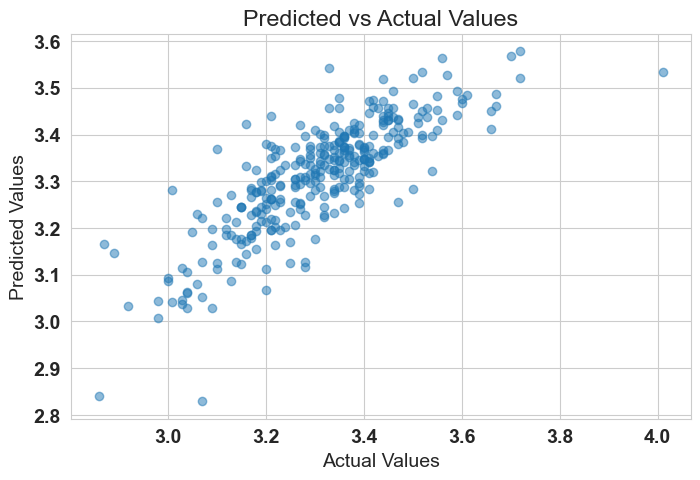

In [67]:
residuals = y_test - y_pred # Calculate difference between actual and predicted
plt.scatter(y_pred, residuals, alpha=0.5) # checks for randomness
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(y=0, color='red', linestyle='--') # Reference line at zero
plt.show()
# shows how well predictions align with real values by comparison Predicted vs Actual
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')

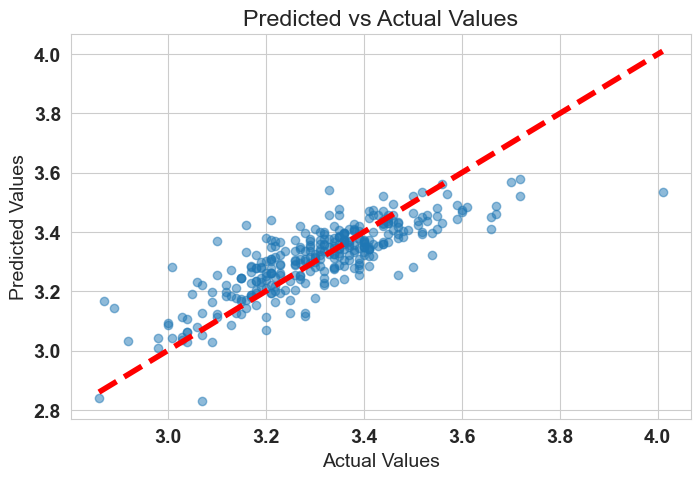

In [68]:
# Predicted vs Actual Plot
plt.scatter(y_test, y_pred, alpha=0.5) # Plot actual vs predicted ph
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=4) #Diagonal reference and perfect prediction lines
plt.show()

R-squared (train): 0.6420461862854046
R-squared (test): 0.653551476495621


Text(0.5, 1.0, 'Predicted vs Actual Values')

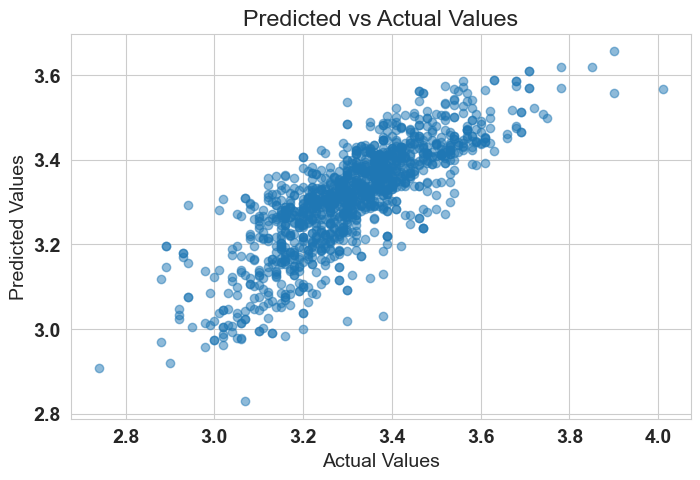

In [69]:
from sklearn.metrics import r2_score
# Predict on training and testing sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluate R squared
print("R-squared (train):", r2_score(y_train, y_pred_train)) #Training fit
print("R-squared (test):", r2_score(y_test, y_pred_test)) #Test fit

# Plot predicted vs actual for training data
plt.scatter(y_train, y_pred_train, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')


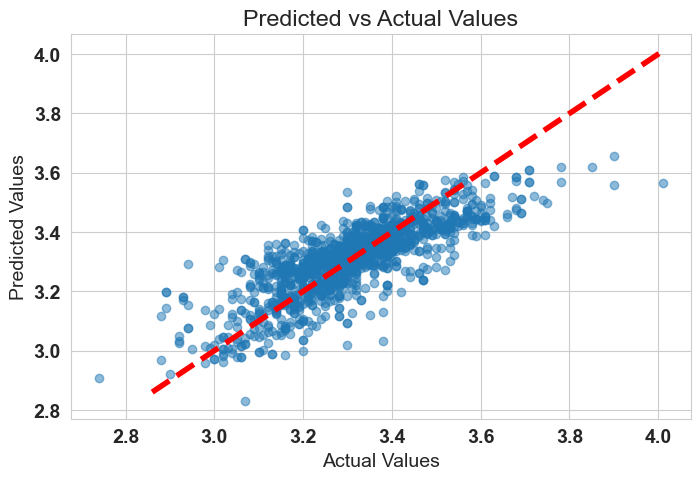

In [70]:
# Plot actual vs predicted values for training data
plt.scatter(y_train, y_pred_train, alpha=0.5)# Scatter plot of predicted vs actual
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=4)# Reference line for perfect prediction
plt.show()

In [71]:
X = df[selected_features]  #independent variables
Y = df['pH'] #target

scaler = StandardScaler() # Standardize features
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42) # Train-test split and model training
model = LinearRegression()
model.fit(X_train, y_train)

intercept = model.intercept_
coefficients = model.coef_
equation = f"pH = {intercept:.3f}"
for coef, feature in zip(coefficients, selected_features):
    sign = " + " if coef >= 0 else " - "
    equation += f"{sign}{abs(coef):.3f} * {feature}"

print("Multiple Linear Regression Equation:")
print(equation)
#Wines with higher fixed acidity so lower pH is more acidic
#Wines with higher density or alcohol so slightly higher pH which is less acidic
#My regression model gives a moderate predictive accuracy R squared is roughly 0.65

Multiple Linear Regression Equation:
pH = 3.312 - 0.140 * fixed acidity - 0.021 * citric acid + 0.086 * density - 0.021 * chlorides - 0.011 * sulphates - 0.003 * volatile acidity + 0.065 * alcohol
